# MP vs Ray 框架一致性对比分析

该 Notebook 用于对比在 `torch.multiprocessing` (MP) 框架与 `Ray` 框架下运行相同算法的结果是否一致。  
主要对比指标：**Accuracy (Top-1)** 和 **Loss**。

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np

# 确保可以导入 utils.py
sys.path.append(os.path.abspath("."))
from utils import ResultLoader, beautify_label

## 1. 配置对比参数

在这里设置你想对比的算法、数据集以及超参数。  
程序会自动从 `results/` (MP) 和 `results_ray/` (Ray) 读取对应的数据。

In [4]:
# ================= 配置区域 =================
ALGO = "fedavg"           # 算法名称
DATASET = "cifar10"       # 数据集
PARTITION = "dirichlet"   # 分区策略
NUM_CLIENTS = 10          # 客户端数量
ROUNDS = 10               # 对比的轮数（绘图截断点）

# 共有超参数 (必须与运行命令一致)
COMMON_ARGS = {
    "epochs": 10,
    "batch_size": 64,
    "lr": 0.01,
    "alpha": 0.1,         # 针对 dirichlet
    # 如果有算法专属参数，请在下方补充
}

# 算法专属参数补充
ALGO_ARGS = {
    "fedproto": {"mu": 0.1},
    "fedprox": {"mu": 0.01},
    "fedrep": {"epochs_head": 5},
    "fedtest": {"mu_test": 0.01},
}

current_algo_args = ALGO_ARGS.get(ALGO, {})
full_args = {**COMMON_ARGS, **current_algo_args}
# ===========================================

## 2. 加载数据

In [8]:
loader_mp = ResultLoader(base_dir="../results")
loader_ray = ResultLoader(base_dir="../results_ray")

print(f"-> Loading results for {ALGO} on {DATASET}...")

# 加载 MP 结果
res_mp = loader_mp.load(ALGO, DATASET, PARTITION, NUM_CLIENTS, specific_run=0, **full_args)

# 加载 Ray 结果
res_ray = loader_ray.load(ALGO, DATASET, PARTITION, NUM_CLIENTS, specific_run=0, **full_args)

if res_mp and res_ray:
    print("✅ Success: Both MP and Ray results found.")
else:
    if not res_mp: print("❌ Error: MP results (results/) not found.")
    if not res_ray: print("❌ Error: Ray results (results_ray/) not found.")

-> Loading results for fedavg on cifar10...
✅ Success: Both MP and Ray results found.


## 3. 结果对比与可视化

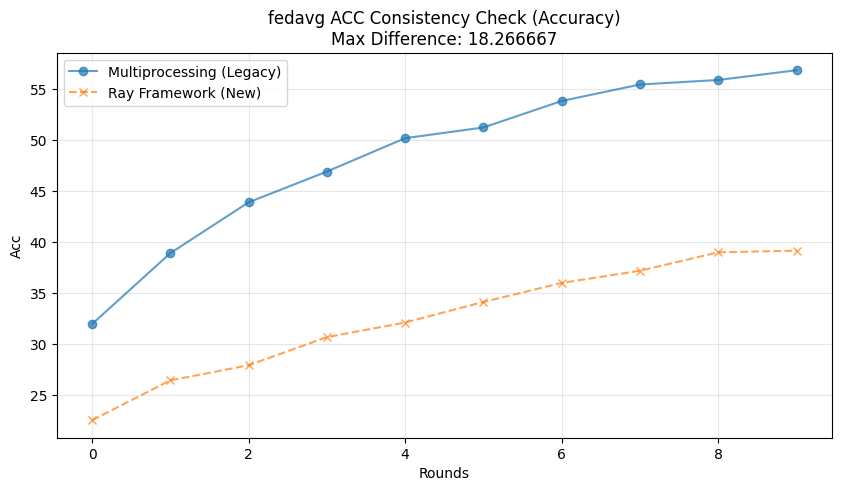

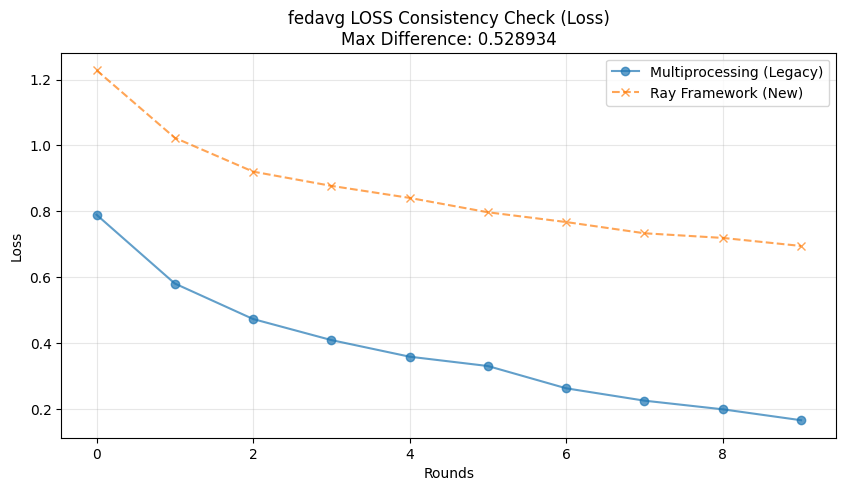

In [9]:
def compare_plots(res_mp, res_ray, metric="acc", title_suffix=""):
    plt.figure(figsize=(10, 5))

    def get_y(data, m):
        val = data.get(m)
        if isinstance(val, dict):
            # 优先取 model 或 local
            k = "model" if "model" in val else "local" if "local" in val else list(val.keys())[0]
            return val[k]
        return val

    y_mp = get_y(res_mp, metric)[:ROUNDS]
    y_ray = get_y(res_ray, metric)[:ROUNDS]

    plt.plot(y_mp, label="Multiprocessing (Legacy)", marker='o', alpha=0.7)
    plt.plot(y_ray, label="Ray Framework (New)", marker='x', linestyle='--', alpha=0.7)

    # 计算最大差异
    diff = np.abs(np.array(y_mp) - np.array(y_ray))
    max_diff = np.max(diff)

    plt.title(f"{ALGO} {metric.upper()} Consistency Check {title_suffix}\nMax Difference: {max_diff:.6f}")
    plt.xlabel("Rounds")
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if res_mp and res_ray:
    compare_plots(res_mp, res_ray, metric="acc", title_suffix="(Accuracy)")
    compare_plots(res_mp, res_ray, metric="loss", title_suffix="(Loss)")